# 📘 Module 23: K-Means Clustering
## Implementing K-Means on a Dataset
## Model Evaluation, Limitations & Use Cases

---

### Why this notebook?
By the end of this notebook, you will be able to:
- Apply K-Means to real data
- Understand what each parameter does
- Visualize clusters clearly
- Evaluate clustering quality
- Know when **not** to use K-Means


## 🔹 Section 1: Import Necessary Libraries


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Explanation
- NumPy and Pandas for data handling
- Matplotlib and Seaborn for visualization
- KMeans from sklearn does the clustering
- StandardScaler is critical because K-Means uses distance
- Silhouette score helps us evaluate clustering quality

> If you skip scaling, K-Means will happily lie to you.


## 🔹 Section 2: Load and Understand the Dataset


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


We will **pretend we do not know** the species labels and focus only on feature-based grouping.


## 🔹 Section 3: Select Features for Clustering


In [5]:
X = df[["sepal_length", "sepal_width"]]
X.head()


,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


We use only two features so clusters are easy to visualize and understand.


## 🔹 Section 4: Feature Scaling (Non-Negotiable)


In [7]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

> K-Means measures distance.
> Distance cares about scale.
> Therefore, scaling is mandatory.


## 🔹 Section 5: Implementing K-Means


In [9]:
#Selecting value of K
k = 3

In [10]:
#Implementing K-Means
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    max_iter=300,
    random_state=42
)

In [11]:
#Data points: 1,2,3,10,11,12
#k=2
#m1=1, m2=10

In [13]:
#Fitting the model
kmeans.fit(X_scaled)

C:\Users\shoye\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

## 🔹 Section 6: Getting Cluster Assignments


In [14]:
#Getting Cluster Assignments
labels = kmeans.labels_
labels[:75]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0], dtype=int32)

In [15]:
df["cluster"]=labels
df.head(150)

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,2
1,4.9,3.0,1.4,0.2,setosa,2
2,4.7,3.2,1.3,0.2,setosa,2
3,4.6,3.1,1.5,0.2,setosa,2
4,5.0,3.6,1.4,0.2,setosa,2
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,0
146,6.3,2.5,5.0,1.9,virginica,1
147,6.5,3.0,5.2,2.0,virginica,0
148,6.2,3.4,5.4,2.3,virginica,0


> These cluster labels are not ground truth. They are just group numbers.


## 🔹 Section 7: Visualizing the Clusters


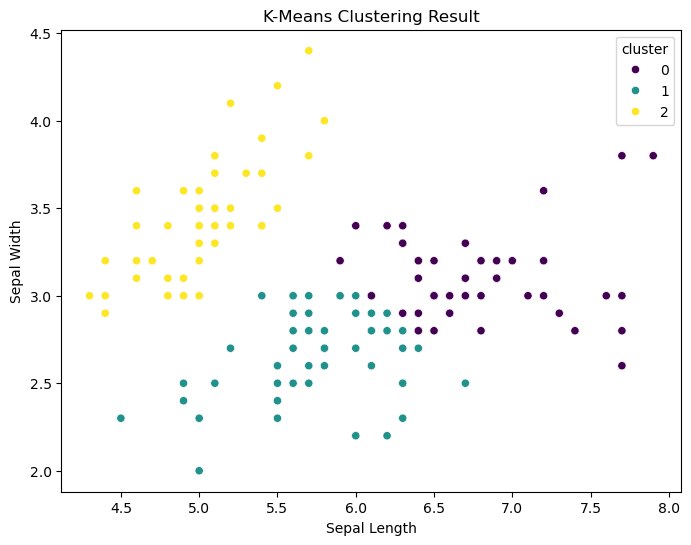

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["sepal_length"],
    y=df["sepal_width"],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("K-Means Clustering Result")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()